# Cox survival results

Figures and tables for the survival analysis. Reads what `cox.py` wrote into
`jsons/cox_results/`.

1. C-index vs. latent dimension
2. Paired per-fold difference between the latent and clinical models
3. Summary table

Style block is shared with `reconstruction-results.ipynb`.

## Error bars
- **Bands on the curves are +-1 SD across folds** -- fold-to-fold variability. Purely
  descriptive, assumes nothing about independence. Not a significance test.
- **Comparisons use paired per-fold differences** with the corrected resampled t-test of
  Nadeau & Bengio (2003): `SE = SD * sqrt(1/n + n_test/n_train)`, replacing the `1/n`
  variance factor. Pairing matters too -- both models see identical folds, so shared
  fold difficulty cancels in the difference.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from scipy import stats as sps

from config import Config

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "legend.frameon": False,
})

## Paths and constants

`LATENT_DIMS` is read off `model_comparison.json` rather than hardcoded, so this notebook
follows whatever `cox.py` last ran on.

In [2]:
cfg = Config()

COX_DIR = Path(cfg.jsons_dir) / "cox_results"
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

BAND = "sd"         # or "sem"

BASELINE = "clinical"           # age + sex, identical folds
LATENT   = "clinical+latent"

model_comparison = json.loads((COX_DIR / "model_comparison.json").read_text())
LATENT_DIMS = sorted(int(t.replace("latent", "")) for t in model_comparison)

DIM_COLORS = dict(zip(LATENT_DIMS, plt.cm.inferno(np.linspace(0.1, 0.75, len(LATENT_DIMS)))))
C_LATENT   = DIM_COLORS[4]
C_BASELINE = "0.35"

# Per-fold scores are the primary source: the summary json only carries mean/std, and the
# paired comparison below needs fold-level pairing that a summary cannot reconstruct.
folds = pd.concat(
    [pd.read_csv(COX_DIR / f"latent{d}_model_folds.csv").assign(dim=d) for d in LATENT_DIMS],
    ignore_index=True,
)

N_FOLDS = folds.groupby(["dim", "model"]).size().unique()
assert len(N_FOLDS) == 1, f"uneven fold counts: {N_FOLDS}"
N_FOLDS = int(N_FOLDS[0])

# Nadeau & Bengio's correction term, taken from the actual split sizes
TEST_TRAIN_RATIO = float((folds["n_test"] / folds["n_train"]).mean())

# Events per variable
N_EVENTS = int(folds["n_events_train"].iloc[0])
EPV = {d: N_EVENTS / (d + 2) for d in LATENT_DIMS}   # +2 for age and sex

print(f"latent dims    : {LATENT_DIMS}")
print(f"folds          : {N_FOLDS} rows per (dim, model)")
print(f"n_test/n_train : {TEST_TRAIN_RATIO:.4f}")
print(f"events (train) : {N_EVENTS}")
print("EPV            : " + ", ".join(f"{d}:{EPV[d]:.1f}" for d in LATENT_DIMS))


latent dims    : [2, 4, 6, 8, 12, 16, 32, 64, 128]
folds          : 30 rows per (dim, model)
n_test/n_train : 0.2500
events (train) : 649
EPV            : 2:162.2, 4:108.2, 6:81.1, 8:64.9, 12:46.4, 16:36.1, 32:19.1, 64:9.8, 128:5.0


## Fold integrity

`_fit_fold_model` in `cox.py` has two distinct outcomes and only one is a failure:

- **Hard failure** -- lifelines raised, so `converged=False` and `test_c` is NaN. The fold
  produces no score.
- **Warned fit** -- lifelines emitted a `ConvergenceWarning` but still returned
  coefficients, so `test_c` is a real number and the warning text is kept in the
  `warnings` column. `converged` stays True.

In [3]:
integrity = folds.groupby(["dim", "model"]).agg(
    n_folds=("test_c", "size"),
    failed=("converged", lambda s: int((~s.astype(bool)).sum())),
    no_score=("test_c", lambda s: int(s.isna().sum())),
    warned=("warnings", lambda s: int(s.notna().sum())),
).reset_index()

N_FAILED, N_WARNED = int(integrity["no_score"].sum()), int(integrity["warned"].sum())
print(f"fold-fits total     : {int(integrity['n_folds'].sum())}")
print(f"hard failures (NaN) : {N_FAILED}")
print(f"warned but usable   : {N_WARNED}")

if N_FAILED or N_WARNED:
    display(integrity[(integrity["no_score"] > 0) | (integrity["warned"] > 0)])
else:
    print("\nNo fold failed or warned, so every dim below uses the full "
          f"{N_FOLDS} pairs and no fold was excluded from any figure or test.")


fold-fits total     : 540
hard failures (NaN) : 0
warned but usable   : 0

No fold failed or warned, so every dim below uses the full 30 pairs and no fold was excluded from any figure or test.


## Uncertainty helpers


In [4]:
def spread(values):
    """Half-width of the plotted band, per the BAND switch. NaN folds are excluded."""
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    return v.std(ddof=1) / np.sqrt(len(v)) if BAND == "sem" else v.std(ddof=1)


BAND_LABEL = {"sem": r"mean $\pm$ SEM", "sd": r"mean $\pm$ 1 SD"}[BAND]
BAND_NOTE  = {"sem": r" - SEM = SD/$\sqrt{n}$, uncorrected", "sd": ""}[BAND]


def nb_ci(values, ratio=TEST_TRAIN_RATIO, alpha=0.05):
    """Nadeau & Bengio (2003) corrected resampled t-interval for a mean over CV folds."""
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]                # n must be surviving pairs, not attempted folds
    n = len(v)
    se = v.std(ddof=1) * np.sqrt(1 / n + ratio)
    half = sps.t.ppf(1 - alpha / 2, n - 1) * se
    return v.mean(), v.mean() - half, v.mean() + half


def naive_ci(values, alpha=0.05):
    """Uncorrected interval, i.e. SD/sqrt(n). Shown only to document what it would claim."""
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    n = len(v)
    half = sps.t.ppf(1 - alpha / 2, n - 1) * v.std(ddof=1) / np.sqrt(n)
    return v.mean(), v.mean() - half, v.mean() + half


print(f"widening factor, corrected vs uncorrected: "
      f"{np.sqrt(1 / N_FOLDS + TEST_TRAIN_RATIO) / np.sqrt(1 / N_FOLDS):.2f}x")

widening factor, corrected vs uncorrected: 2.92x


## 1. C-index vs. latent dimension

Held-out Harrell's C against the age+sex baseline.

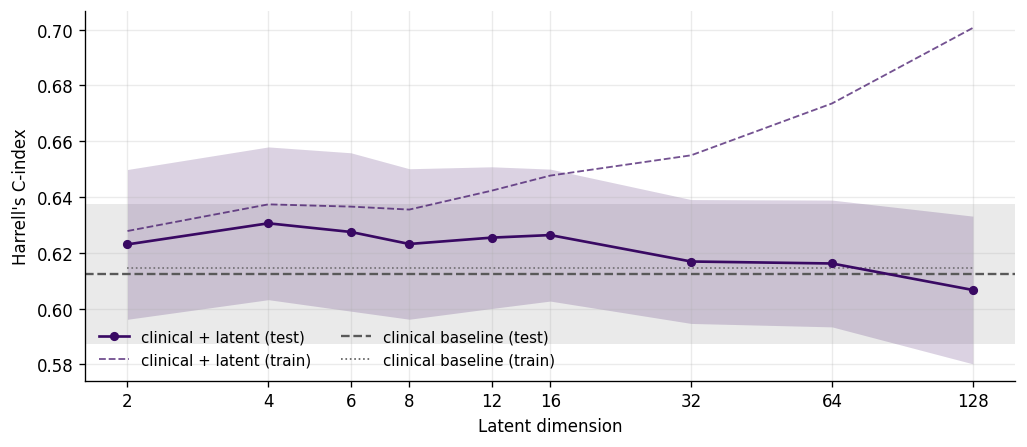

In [5]:
def series(model, col):
    g = folds[folds["model"] == model].groupby("dim")[col]
    return (g.mean().reindex(LATENT_DIMS).values,
            g.apply(spread).reindex(LATENT_DIMS).values)


base_test = folds[folds["model"] == BASELINE].groupby("dim")["test_c"].mean()
assert np.ptp(base_test.values) < 1e-9, "baseline drifts across dims - folds are not shared"
base_vals = folds[(folds["model"] == BASELINE) & (folds["dim"] == LATENT_DIMS[0])]["test_c"]
base_mean, base_sd = base_vals.mean(), spread(base_vals)

lat_test_m, lat_test_s = series(LATENT, "test_c")
lat_train_m, _         = series(LATENT, "train_c")
base_train_m, _        = series(BASELINE, "train_c")

fig, ax = plt.subplots(figsize=(10, 4))

# Baseline: flat reference line + its own SD band
ax.axhspan(base_mean - base_sd, base_mean + base_sd, color=C_BASELINE, alpha=0.12, lw=0)
ax.axhline(base_mean, color=C_BASELINE, ls="--", lw=1.4)
ax.plot(LATENT_DIMS, base_train_m, color=C_BASELINE, ls=":", lw=1.0, alpha=0.8)

# Latent model
ax.fill_between(LATENT_DIMS, lat_test_m - lat_test_s, lat_test_m + lat_test_s,
                color=C_LATENT, alpha=0.18, lw=0)
ax.plot(LATENT_DIMS, lat_test_m, marker="o", ms=4.5, lw=1.6, color=C_LATENT)
ax.plot(LATENT_DIMS, lat_train_m, ls="--", lw=1.1, color=C_LATENT, alpha=0.7)

ax.set_xscale("log", base=2)
ax.set_xticks(LATENT_DIMS)
ax.get_xaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
ax.minorticks_off()
ax.set_xlabel("Latent dimension")
ax.set_ylabel("Harrell's C-index")

ax.legend(handles=[
    Line2D([], [], color=C_LATENT, marker="o", ms=4.5, lw=1.6, label="clinical + latent (test)"),
    Line2D([], [], color=C_LATENT, ls="--", lw=1.1, alpha=0.7, label="clinical + latent (train)"),
    Line2D([], [], color=C_BASELINE, ls="--", lw=1.4, label="clinical baseline (test)"),
    Line2D([], [], color=C_BASELINE, ls=":", lw=1.0, label="clinical baseline (train)"),
], loc="lower left", ncol=2, fontsize=9)


fig.savefig(FIG_DIR / "cox_cindex_vs_latent_dim.pdf")
fig.savefig(FIG_DIR / "cox_cindex_vs_latent_dim.png")

## 2. Paired per-fold difference

The comparison that licenses a claim. Per fold, `C(clinical+latent) - C(clinical)` on the
identical test patients; positive means the latent codes add prognostic information
beyond age and sex.

Pairing alone roughly halves the noise (SD of the difference is ~0.014 at dim 4, versus
~0.025 for either model alone) because shared fold difficulty cancels. The uncorrected
interval is drawn in grey for contrast only -- the corrected one is what to report.

In [7]:
paired = folds.pivot_table(index=["dim", "fold"], columns="model", values="test_c")

rows = []
for d in LATENT_DIMS:
    # Pairwise-complete: a fold counts only if BOTH models scored it
    pair = paired.loc[d, [BASELINE, LATENT]].dropna()
    diff = (pair[LATENT] - pair[BASELINE]).values
    m, lo, hi = nb_ci(diff)
    _, nlo, nhi = naive_ci(diff)
    rows.append({
        "dim": d,
        "n_pairs": len(diff),
        "mean_delta": m, "sd_delta": diff.std(ddof=1),
        "folds_won": int((diff > 0).sum()),
        "nb_lo": lo, "nb_hi": hi,
        "naive_lo": nlo, "naive_hi": nhi,
        "nb_sig": lo > 0 or hi < 0,
        "naive_sig": nlo > 0 or nhi < 0,
    })
delta = pd.DataFrame(rows)

# fig, ax = plt.subplots(figsize=(10, 4))
# x = delta["dim"].values

# ax.axhline(0, color="0.3", lw=1.0, ls="-", zorder=1)
# ax.vlines(x, delta["naive_lo"], delta["naive_hi"], color="0.6", lw=3.5, alpha=0.45, zorder=2)
# ax.vlines(x, delta["nb_lo"], delta["nb_hi"], color=C_LATENT, lw=1.4, zorder=3)
# ax.plot(x, delta["mean_delta"], "o", ms=5.5, color=C_LATENT, zorder=4)

# for _, r in delta.iterrows():
#     ax.annotate(f"{r['folds_won']:.0f}/{r['n_pairs']:.0f}", (r["dim"], r["nb_hi"]),
#                 textcoords="offset points", xytext=(0, 5),
#                 ha="center", fontsize=7.5, color="0.4")

# ax.set_xscale("log", base=2)
# ax.set_xticks(LATENT_DIMS)
# ax.get_xaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
# ax.minorticks_off()
# ax.set_xlabel("Latent dimension")
# ax.set_ylabel(r"$\Delta$ C-index (latent $-$ clinical)")

# ax.legend(handles=[
#     Line2D([], [], color=C_LATENT, marker="o", ms=5.5, lw=1.4,
#            label="mean, 95% CI (Nadeau & Bengio corrected)"),
#     Line2D([], [], color="0.6", lw=3.5, alpha=0.45, label="95% CI (uncorrected)"),
# ], loc="lower left", fontsize=9)
# n_pairs_note = (f"the same {N_FOLDS} folds" if (delta["n_pairs"] == N_FOLDS).all()
#                 else "complete pairs only (see labels)")
# ax.set_title(f"Paired across {n_pairs_note}; labels = folds won",
#              fontsize=9, loc="left", color="0.35")

# fig.savefig(FIG_DIR / "cox_paired_delta.pdf")
# fig.savefig(FIG_DIR / "cox_paired_delta.png")

if (delta["n_pairs"] < N_FOLDS).any():
    print("dims with dropped pairs:",
          delta.loc[delta["n_pairs"] < N_FOLDS, ["dim", "n_pairs"]].to_dict("records"))
print("dims significant, corrected  :", delta.loc[delta['nb_sig'], 'dim'].tolist())
print("dims significant, uncorrected:", delta.loc[delta['naive_sig'], 'dim'].tolist())

dims significant, corrected  : [4]
dims significant, uncorrected: [2, 4, 6, 8, 12, 16]


## 3. Summary table

Per-model mean +- SD, the paired difference with its corrected interval, and EPV as
context for the decay at high dimension. The significance column comes from the paired
corrected CI, never from the +- column. "Folds won" is out of the number of complete
pairs, which equals the fold count unless a fit hard-failed.

In [8]:
def fmt(m, s):
    # SEMs sit around 0.005, so 3 dp collapses every row to the same value
    dp = 4 if BAND == "sem" else 3
    return f"{m:.{dp}f} $\\pm$ {s:.{dp}f}"


records = []
for i, d in enumerate(LATENT_DIMS):
    r = delta[delta["dim"] == d].iloc[0]
    records.append({
        "Latent dim":   d,
        f"Clinical ({BAND.upper()})":        fmt(base_mean, base_sd),
        f"Clinical+latent ({BAND.upper()})": fmt(lat_test_m[i], lat_test_s[i]),
        "Delta C":      f"{r['mean_delta']:+.4f}",
        "95% CI":       f"[{r['nb_lo']:+.4f}, {r['nb_hi']:+.4f}]",
        "Folds won":    f"{r['folds_won']:.0f}/{r['n_pairs']:.0f}",
        "EPV":          f"{EPV[d]:.1f}",
        "Sig.":         "yes" if r["nb_sig"] else "no",
    })

table = pd.DataFrame(records).set_index("Latent dim")
table.to_csv(FIG_DIR / "cox_cindex_summary.csv")
(FIG_DIR / "cox_cindex_summary.tex").write_text(table.to_latex(escape=False))
table

,Clinical (SD),Clinical+latent (SD),Delta C,95% CI,Folds won,EPV,Sig.
Latent dim,,,,,,,
2,0.612 $\pm$ 0.025,0.623 $\pm$ 0.027,+0.0106,"[-0.0037, +0.0248]",25/30,162.2,no
4,0.612 $\pm$ 0.025,0.631 $\pm$ 0.027,+0.0181,"[+0.0027, +0.0335]",28/30,108.2,yes
6,0.612 $\pm$ 0.025,0.627 $\pm$ 0.028,+0.0150,"[-0.0014, +0.0314]",26/30,81.1,no
8,0.612 $\pm$ 0.025,0.623 $\pm$ 0.027,+0.0107,"[-0.0043, +0.0257]",25/30,64.9,no
12,0.612 $\pm$ 0.025,0.625 $\pm$ 0.025,+0.0130,"[-0.0031, +0.0291]",24/30,46.4,no
16,0.612 $\pm$ 0.025,0.626 $\pm$ 0.024,+0.0139,"[-0.0034, +0.0312]",24/30,36.1,no
32,0.612 $\pm$ 0.025,0.617 $\pm$ 0.022,+0.0044,"[-0.0179, +0.0268]",19/30,19.1,no
64,0.612 $\pm$ 0.025,0.616 $\pm$ 0.023,+0.0037,"[-0.0198, +0.0273]",17/30,9.8,no
128,0.612 $\pm$ 0.025,0.607 $\pm$ 0.026,-0.0058,"[-0.0327, +0.0212]",12/30,5.0,no
